In [45]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error

In [46]:
df=pd.read_csv('C:\\Users\\Sowndarya\\OneDrive\\Desktop\\DataAnalytics\\AI&ML\\Project-ML\\Regression_dataset\\train.csv')

In [47]:
df

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1
2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2
3,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1
...,...,...,...,...,...,...,...,...
49995,2013-06-12 23:25:15.0000004,15.0,2013-06-12 23:25:15 UTC,-73.999973,40.748531,-74.016899,40.705993,1
49996,2015-06-22 17:19:18.0000007,7.5,2015-06-22 17:19:18 UTC,-73.984756,40.768211,-73.987366,40.760597,1
49997,2011-01-30 04:53:00.00000063,6.9,2011-01-30 04:53:00 UTC,-74.002698,40.739428,-73.998108,40.759483,1
49998,2012-11-06 07:09:00.00000069,4.5,2012-11-06 07:09:00 UTC,-73.946062,40.777567,-73.953450,40.779687,2


In [48]:
df.head(2)

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1


In [49]:
df.tail(10)

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
49990,2013-07-18 00:16:00.00000027,4.5,2013-07-18 00:16:00 UTC,-74.002857,40.734137,-74.001610,40.739282,1
49991,2013-10-17 19:56:19.0000002,10.5,2013-10-17 19:56:19 UTC,-73.991685,40.739494,-73.985357,40.731971,1
49992,2009-06-06 10:41:47.0000003,6.1,2009-06-06 10:41:47 UTC,-73.984673,40.768434,-73.988215,40.760082,1
49993,2011-04-07 14:27:00.000000130,7.3,2011-04-07 14:27:00 UTC,-73.982363,40.765060,-73.969167,40.761268,1
49994,2012-10-13 19:57:00.000000161,8.5,2012-10-13 19:57:00 UTC,-73.976212,40.744832,-73.981567,40.724635,1
49995,2013-06-12 23:25:15.0000004,15.0,2013-06-12 23:25:15 UTC,-73.999973,40.748531,-74.016899,40.705993,1
49996,2015-06-22 17:19:18.0000007,7.5,2015-06-22 17:19:18 UTC,-73.984756,40.768211,-73.987366,40.760597,1
49997,2011-01-30 04:53:00.00000063,6.9,2011-01-30 04:53:00 UTC,-74.002698,40.739428,-73.998108,40.759483,1
49998,2012-11-06 07:09:00.00000069,4.5,2012-11-06 07:09:00 UTC,-73.946062,40.777567,-73.953450,40.779687,2
49999,2010-01-13 08:13:14.0000007,10.9,2010-01-13 08:13:14 UTC,-73.932603,40.763805,-73.932603,40.763805,1


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   key                50000 non-null  object 
 1   fare_amount        50000 non-null  float64
 2   pickup_datetime    50000 non-null  object 
 3   pickup_longitude   50000 non-null  float64
 4   pickup_latitude    50000 non-null  float64
 5   dropoff_longitude  50000 non-null  float64
 6   dropoff_latitude   50000 non-null  float64
 7   passenger_count    50000 non-null  int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 3.1+ MB


In [51]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,11.364171,-72.509756,39.933759,-72.504616,39.926251,1.667840
std,9.685557,10.393860,6.224857,10.407570,6.014737,1.289195
min,-5.000000,-75.423848,-74.006893,-84.654241,-74.006377,0.000000
25%,6.000000,-73.992062,40.734880,-73.991152,40.734372,1.000000
50%,8.500000,-73.981840,40.752678,-73.980082,40.753372,1.000000
75%,12.500000,-73.967148,40.767360,-73.963584,40.768167,2.000000
max,200.000000,40.783472,401.083332,40.851027,43.415190,6.000000


In [52]:
df.columns

Index(['key', 'fare_amount', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count'],
      dtype='object')

In [53]:
df.isnull().sum()

key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

In [54]:
df.dtypes

key                   object
fare_amount          float64
pickup_datetime       object
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object

In [55]:
df['key']=pd.to_datetime(df['key'])
df['pickup_datetime']=pd.to_datetime(df['pickup_datetime'])

In [56]:
df.dtypes

key                       datetime64[ns]
fare_amount                      float64
pickup_datetime      datetime64[ns, UTC]
pickup_longitude                 float64
pickup_latitude                  float64
dropoff_longitude                float64
dropoff_latitude                 float64
passenger_count                    int64
dtype: object

In [57]:
df

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2009-06-15 17:26:21.000000100,4.5,2009-06-15 17:26:21+00:00,-73.844311,40.721319,-73.841610,40.712278,1
1,2010-01-05 16:52:16.000000200,16.9,2010-01-05 16:52:16+00:00,-74.016048,40.711303,-73.979268,40.782004,1
2,2011-08-18 00:35:00.000000490,5.7,2011-08-18 00:35:00+00:00,-73.982738,40.761270,-73.991242,40.750562,2
3,2012-04-21 04:30:42.000000100,7.7,2012-04-21 04:30:42+00:00,-73.987130,40.733143,-73.991567,40.758092,1
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00+00:00,-73.968095,40.768008,-73.956655,40.783762,1
...,...,...,...,...,...,...,...,...
49995,2013-06-12 23:25:15.000000400,15.0,2013-06-12 23:25:15+00:00,-73.999973,40.748531,-74.016899,40.705993,1
49996,2015-06-22 17:19:18.000000700,7.5,2015-06-22 17:19:18+00:00,-73.984756,40.768211,-73.987366,40.760597,1
49997,2011-01-30 04:53:00.000000630,6.9,2011-01-30 04:53:00+00:00,-74.002698,40.739428,-73.998108,40.759483,1
49998,2012-11-06 07:09:00.000000690,4.5,2012-11-06 07:09:00+00:00,-73.946062,40.777567,-73.953450,40.779687,2


In [58]:
df['key']=df['key'].astype(int)
df['pickup_datetime']=df['pickup_datetime'].astype(int)

In [59]:
df.dtypes

key                    int64
fare_amount          float64
pickup_datetime        int64
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object

In [60]:
df

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,1245086781000000100,4.5,1245086781000000000,-73.844311,40.721319,-73.841610,40.712278,1
1,1262710336000000200,16.9,1262710336000000000,-74.016048,40.711303,-73.979268,40.782004,1
2,1313627700000000490,5.7,1313627700000000000,-73.982738,40.761270,-73.991242,40.750562,2
3,1334982642000000100,7.7,1334982642000000000,-73.987130,40.733143,-73.991567,40.758092,1
4,1268121060000000135,5.3,1268121060000000000,-73.968095,40.768008,-73.956655,40.783762,1
...,...,...,...,...,...,...,...,...
49995,1371079515000000400,15.0,1371079515000000000,-73.999973,40.748531,-74.016899,40.705993,1
49996,1434993558000000700,7.5,1434993558000000000,-73.984756,40.768211,-73.987366,40.760597,1
49997,1296363180000000630,6.9,1296363180000000000,-74.002698,40.739428,-73.998108,40.759483,1
49998,1352185740000000690,4.5,1352185740000000000,-73.946062,40.777567,-73.953450,40.779687,2


In [61]:
x=df.drop(columns='fare_amount',axis=1)
y=df['fare_amount']

In [62]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [63]:
print(x)

                       key      pickup_datetime  pickup_longitude  \
0      1245086781000000100  1245086781000000000        -73.844311   
1      1262710336000000200  1262710336000000000        -74.016048   
2      1313627700000000490  1313627700000000000        -73.982738   
3      1334982642000000100  1334982642000000000        -73.987130   
4      1268121060000000135  1268121060000000000        -73.968095   
...                    ...                  ...               ...   
49995  1371079515000000400  1371079515000000000        -73.999973   
49996  1434993558000000700  1434993558000000000        -73.984756   
49997  1296363180000000630  1296363180000000000        -74.002698   
49998  1352185740000000690  1352185740000000000        -73.946062   
49999  1263370394000000700  1263370394000000000        -73.932603   

       pickup_latitude  dropoff_longitude  dropoff_latitude  passenger_count  
0            40.721319         -73.841610         40.712278                1  
1            

In [64]:
print(y)

0         4.5
1        16.9
2         5.7
3         7.7
4         5.3
         ... 
49995    15.0
49996     7.5
49997     6.9
49998     4.5
49999    10.9
Name: fare_amount, Length: 50000, dtype: float64


In [65]:
model=LinearRegression()

In [66]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [67]:
y_pred=model.predict(x_test)
print(y_pred)

[12.03856921 12.99196369 12.90020634 ... 13.3057215  11.10083911
 13.04883645]


In [69]:
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

In [70]:
print(mse)
print(r2)

91.51041460485688
0.012130866079555047


In [72]:
import matplotlib.pyplot as plt

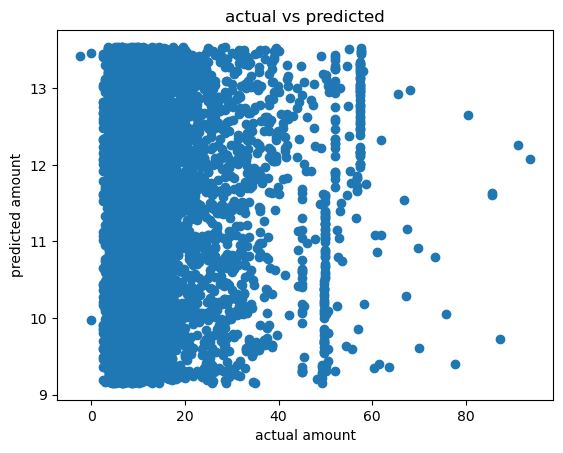

In [73]:
plt.figure()
plt.scatter(y_test,y_pred)
plt.xlabel("actual amount")
plt.ylabel("predicted amount")
plt.title("actual vs predicted")
plt.show()


In [78]:
newdata=[[1316385000000000144,1316385000000000000,-73.950655,40.722588,-73.962512,40.761261,5]]

In [79]:
output_prdctn=model.predict(newdata)
print(output_prdctn)

[10.9850107]


C:\Users\Sowndarya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [87]:
output_prdctn_np =np.round(output_prdctn,2)
print(output_prdctn_np)

[10.99]
